In [1]:
import pandas as pd

file_path = r"C:\Users\Sneha G\Downloads\online+retail\Online Retail.xlsx"

df = pd.read_excel(file_path)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [1]:
df.shape

NameError: name 'df' is not defined

In [2]:
import pandas as pd

file_path = r"C:\Users\Sneha G\Downloads\online+retail\Online Retail.xlsx"

df = pd.read_excel(file_path)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.duplicated().sum()

5268

In [8]:
df['CustomerID'].isnull().sum()

135080

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [10]:
df = df.dropna(subset=['CustomerID'])

In [11]:
df.shape

(406829, 8)

In [12]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [13]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

In [14]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,0.00
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [15]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,92.047118,5.075480,1898.459701
std,100.765435,9.338754,8219.345141
min,1.000000,1.000000,-4287.630000
25%,17.000000,1.000000,293.362500
50%,50.000000,3.000000,648.075000
75%,143.000000,5.000000,1611.725000
max,374.000000,248.000000,279489.020000


In [16]:
features = rfm[['Recency', 'Frequency', 'Monetary']]

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(features)

ModuleNotFoundError: No module named 'sklearn'

In [18]:
%pip install scikit-learn

   ---------------------------------------- 7.1/7.1 MB 25.2 MB/s eta 0:00:00
   --------------------------------------- 302.2/302.2 kB 19.5 MB/s eta 0:00:00
   ---------------------------------------- 34.1/34.1 MB 21.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(features)

NameError: name 'features' is not defined

In [2]:
features = rfm[['Recency', 'Frequency', 'Monetary']]

NameError: name 'rfm' is not defined

In [3]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

NameError: name 'df' is not defined

In [4]:
import pandas as pd

file_path = r"C:\Users\Sneha G\Downloads\online+retail\Online Retail.xlsx"

df = pd.read_excel(file_path)

In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [6]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [7]:
df = df.dropna(subset=['CustomerID'])

In [8]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [9]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

In [10]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,0.00
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [11]:
features = rfm[['Recency', 'Frequency', 'Monetary']]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

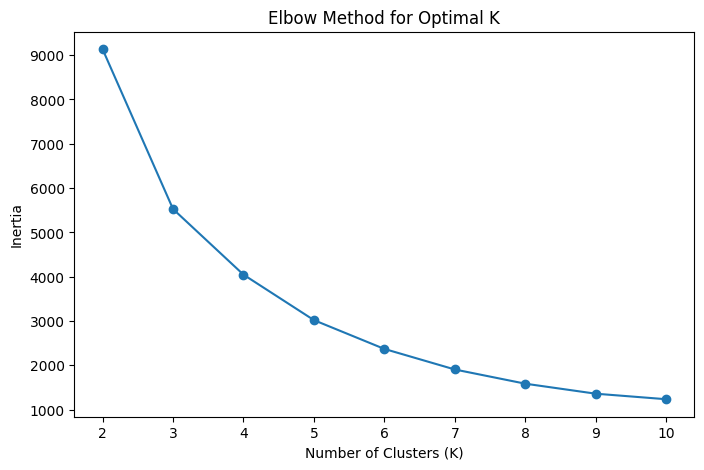

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [14]:
rfm['Cluster'].value_counts().sort_index()

0    3169
1       6
2    1087
3     110
Name: Cluster, dtype: int64

In [15]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,41.606500,4.802461,1478.515539
1,7.666667,89.000000,182181.981667
2,247.951242,1.805888,453.488888
3,9.181818,40.672727,18441.961455


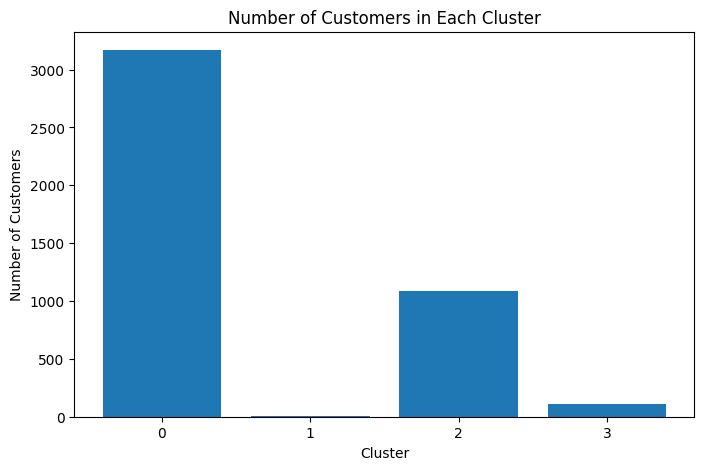

In [16]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Cluster')
plt.xticks(cluster_counts.index)
plt.show()

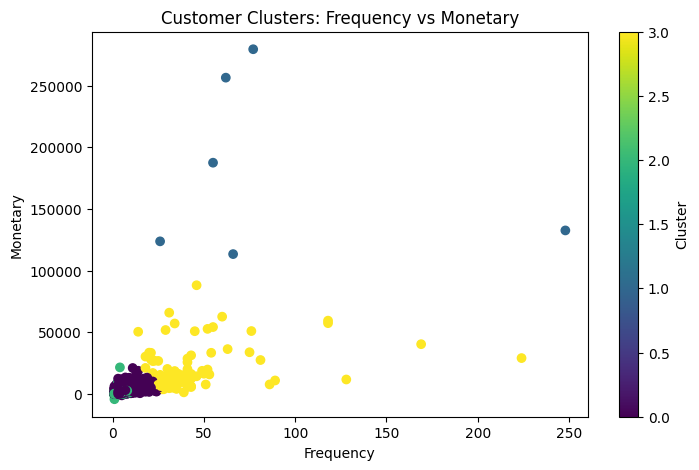

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis'
)

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Clusters: Frequency vs Monetary')
plt.colorbar(label='Cluster')
plt.show()

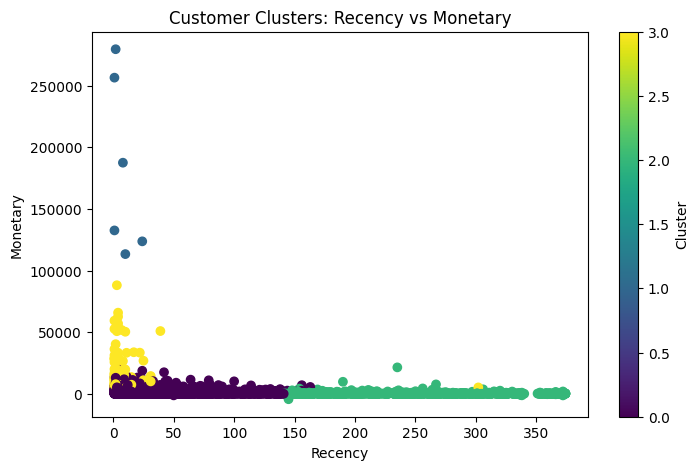

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    rfm['Recency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis'
)

plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Clusters: Recency vs Monetary')
plt.colorbar(label='Cluster')
plt.show()

In [19]:
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,41.61,4.80,1478.52
1,7.67,89.00,182181.98
2,247.95,1.81,453.49
3,9.18,40.67,18441.96


In [20]:
cluster_profile.round(2).to_csv('cluster_profile.csv')

In [21]:
cluster_names = {
    0: 'Regular Customers',
    1: 'High-Value Customers',
    2: 'At-Risk Customers',
    3: 'Loyal Customers'
}

rfm['Customer Segment'] = rfm['Cluster'].map(cluster_names)

rfm[['CustomerID', 'Cluster', 'Customer Segment']].head()

,CustomerID,Cluster,Customer Segment
0,12346.0,2,At-Risk Customers
1,12347.0,0,Regular Customers
2,12348.0,0,Regular Customers
3,12349.0,0,Regular Customers
4,12350.0,2,At-Risk Customers


In [22]:
rfm['Customer Segment'].value_counts()

Regular Customers       3169
At-Risk Customers       1087
Loyal Customers          110
High-Value Customers       6
Name: Customer Segment, dtype: int64

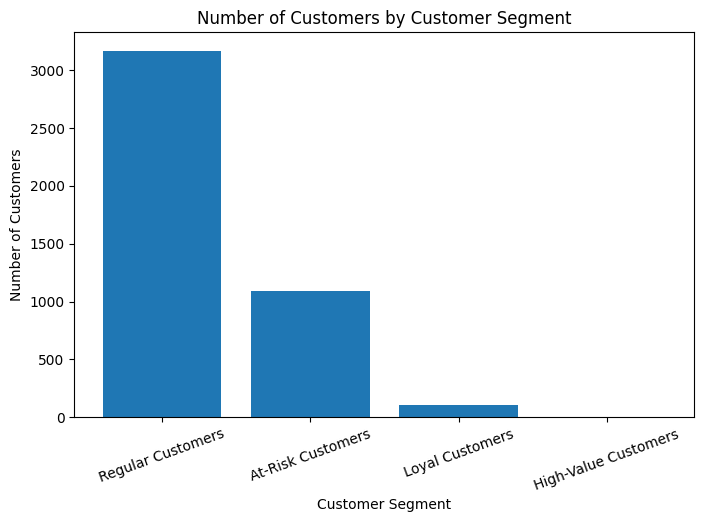

In [23]:
segment_counts = rfm['Customer Segment'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(segment_counts.index, segment_counts.values)
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Number of Customers by Customer Segment')
plt.xticks(rotation=20)
plt.show()

## Marketing Insights

### High-Value Customers
Offer loyalty rewards, premium products, and personalized promotions to retain these customers.

### Loyal Customers
Encourage repeat purchases through loyalty programs, member benefits, and exclusive offers.

### Regular Customers
Use personalized recommendations, discounts, and targeted campaigns to increase purchase frequency.

### At-Risk Customers
Send re-engagement offers, reminders, and special discounts to encourage them to return.

## Conclusion

The customer segmentation analysis grouped customers into four distinct segments using RFM features and K-Means clustering. The segments show differences in customer purchasing behaviour based on recency, frequency, and monetary value.

These segments can help businesses design targeted marketing strategies, improve customer retention, encourage repeat purchases, and re-engage customers who may be at risk of becoming inactive.